
# Expiry-to-Demand Match Engine

This notebook builds an **AI-driven Expiry-to-Demand Matching Engine**.

### Purpose
Identify expiring inventory and determine **which region can sell it fastest** before expiration.

### Inputs
- Product inventory
- Expiry dates
- Regional demand velocity

### Outputs
- Best region to push stock
- Days to clear inventory
- Financial value at risk
- Recommended sales action


In [1]:

!pip install pandas numpy matplotlib


In [2]:

import pandas as pd
import numpy as np
from datetime import datetime



## Upload Dataset

Upload:

pioneer_pharma_ideal_dataset_70000_rows.csv


In [ ]:

from google.colab import files
uploaded = files.upload()


## Load Dataset

In [4]:

df = pd.read_csv("pioneer_pharma_ideal_dataset_70000_rows.csv")

df.head()


,order_id,order_date,sku_id,product_name,batch_id,region,warehouse,transaction_type,quantity,unit_price_iqd,revenue_iqd,expiry_date,production_status
0,SO-100000,2024-04-12,SKU-1007,ATRANEER 10mg/ml Injection,BATCH-771155,Basra,WH 1-50,Sale,232,1100,255200,2025-02-07,Completed
1,SO-100001,2025-04-11,SKU-1003,NAPRON 500mg Tablet,BATCH-621430,Mosul,WH 1-50,Sale,204,450,91800,2026-09-16,Released
2,SO-100002,2025-05-06,SKU-1007,ATRANEER 10mg/ml Injection,BATCH-427069,Baghdad-Karkh,WH 1-70,Sale,187,1100,205700,2027-02-04,In Progress
3,SO-100003,2024-11-09,SKU-1004,SITAVIA Plus 50/1000mg,BATCH-521909,Baghdad-Rusafa,WH 2-400,Sale,201,900,180900,2025-11-13,In Progress
4,SO-100004,2025-11-17,SKU-1005,SITAVIA 100mg Tablets,BATCH-691723,Baghdad-Karkh,WH 1-70,Sale,201,850,170850,2026-06-05,In Progress


## Convert Date Columns

In [5]:

df["order_date"] = pd.to_datetime(df["order_date"])
df["expiry_date"] = pd.to_datetime(df["expiry_date"])


## Calculate Days to Expiry

In [6]:

today = pd.Timestamp(datetime.today())

df["days_to_expiry"] = (df["expiry_date"] - today).dt.days


## Filter Sales Transactions

In [7]:

sales_df = df[df["transaction_type"] == "Sale"]



## Estimate Regional Demand Velocity


In [8]:

demand = sales_df.groupby(["region","product_name"])["quantity"].sum().reset_index()

demand.rename(columns={"quantity":"predicted_demand"}, inplace=True)

demand.head()


,region,product_name,predicted_demand
0,Baghdad-Karkh,ATRANEER 10mg/ml Injection,249014
1,Baghdad-Karkh,CLAFONEER 500mg IV/IM Vial,278504
2,Baghdad-Karkh,CLOXABAN 20mg F/C Tablet,256039
3,Baghdad-Karkh,LOSART 50mg Tablets,265934
4,Baghdad-Karkh,NAPRON 500mg Tablet,277976


## Calculate Daily Demand

In [9]:

demand["daily_demand"] = demand["predicted_demand"] / 30



## Expiry-to-Demand Matching Logic


In [10]:

results = []

for _, batch in df.iterrows():

    product = batch["product_name"]
    stock = batch["quantity"]

    regional = demand[demand["product_name"] == product]

    if regional.empty:
        continue

    regional = regional.copy()

    regional["days_to_clear"] = stock / regional["daily_demand"]

    best_region = regional.sort_values("days_to_clear").iloc[0]

    value_at_risk = stock * batch["unit_price_iqd"]

    results.append({
        "product": product,
        "batch": batch["batch_id"],
        "best_region": best_region["region"],
        "days_to_expiry": batch["days_to_expiry"],
        "days_to_clear": best_region["days_to_clear"],
        "value_at_risk": value_at_risk
    })

match_results = pd.DataFrame(results)

match_results.head()


,product,batch,best_region,days_to_expiry,days_to_clear,value_at_risk
0,ATRANEER 10mg/ml Injection,BATCH-771155,Mosul,-400,0.025636,255200
1,NAPRON 500mg Tablet,BATCH-621430,Baghdad-Karkh,186,0.022016,91800
2,ATRANEER 10mg/ml Injection,BATCH-427069,Mosul,327,0.020663,205700
3,SITAVIA Plus 50/1000mg,BATCH-521909,Basra,-121,0.022117,180900
4,SITAVIA 100mg Tablets,BATCH-691723,Mosul,83,0.021702,170850



## Generate Recommended Actions


In [11]:

def recommend_action(row):

    if row["days_to_clear"] < row["days_to_expiry"] * 0.5:
        return "Push to region"

    elif row["days_to_clear"] > row["days_to_expiry"]:
        return "Promote aggressively"

    else:
        return "Bundle discount"

match_results["recommended_action"] = match_results.apply(recommend_action, axis=1)

match_results.head()


,product,batch,best_region,days_to_expiry,days_to_clear,value_at_risk,recommended_action
0,ATRANEER 10mg/ml Injection,BATCH-771155,Mosul,-400,0.025636,255200,Promote aggressively
1,NAPRON 500mg Tablet,BATCH-621430,Baghdad-Karkh,186,0.022016,91800,Push to region
2,ATRANEER 10mg/ml Injection,BATCH-427069,Mosul,327,0.020663,205700,Push to region
3,SITAVIA Plus 50/1000mg,BATCH-521909,Basra,-121,0.022117,180900,Promote aggressively
4,SITAVIA 100mg Tablets,BATCH-691723,Mosul,83,0.021702,170850,Push to region


## Financial Risk Summary

In [12]:

total_risk = match_results["value_at_risk"].sum()

print("Total Value at Risk (IQD):", total_risk)


Total Value at Risk (IQD): 10709089450


## Value at Risk Visualization

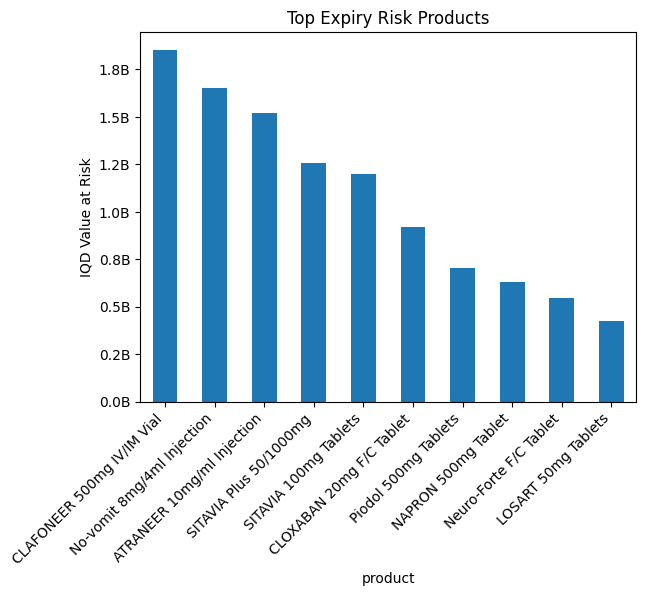

In [17]:
product_risk = match_results.groupby("product")["value_at_risk"].sum().reset_index()

product_risk = product_risk.sort_values(by="value_at_risk", ascending=False)

product_risk.head(10).plot(
    x="product",
    y="value_at_risk",
    kind="bar",
    legend=False
)

plt.title("Top Expiry Risk Products")
plt.ylabel("IQD Value at Risk")

plt.xticks(rotation=45, ha="right")

import matplotlib.ticker as ticker
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B')
)

plt.show()